# check  cdr RMSD 

### 각 pdb별 샘플들의 h3 cdr RMSD 분포 체크

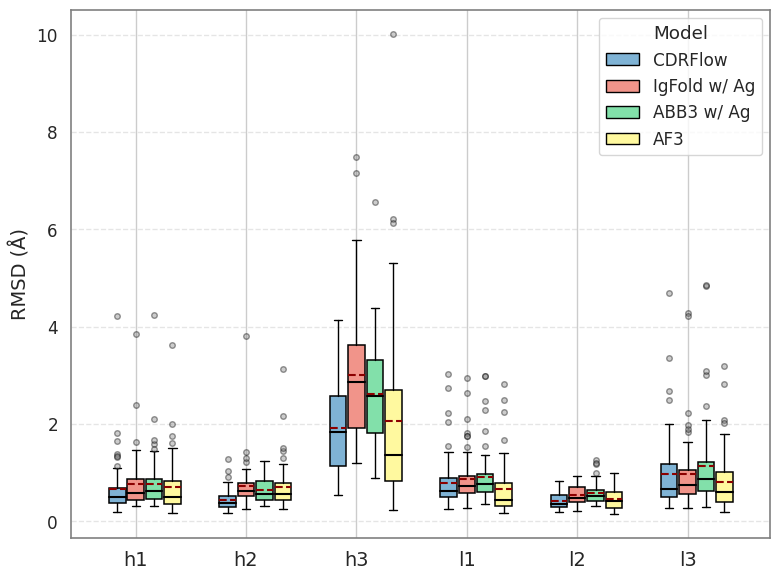

In [31]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import seaborn as sns
from Bio.PDB import PDBParser

def calculate_b_factor_mean(pdb_dir, start_residue=95, end_residue=102):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in os.listdir(pdb_dir):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    # 각 원자의 B-factor 가져오기
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())
                
        b_factors_avg.append(np.mean(b_factors))
        max_index = int(np.argmax(b_factors_avg))
    return max_index


pred_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
igfold_dir = '/home/psh/igfold_esm/test_code/eval_model/benchmark_after210930/real_original/only_cdr'
prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/af3_output_processed'
csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

rmsd_by_pdb = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_igfold = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_prev = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_af3 = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
keys = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']
pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 이전 프로젝트에서 RMSD 값 불러오기
    prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
    if os.path.exists(prev_filepath):
        with open(prev_filepath, 'r') as f:
            prev_data = json.load(f)
        for key in keys:
            h3_rmsd_by_pdb_prev[key].append(prev_data[f'{key}_rms'])
    else:
        continue
    
    # Igfold에서 RMSD 가져오기 
    igfold_filepath = os.path.join(igfold_dir, pdb_id + '.json')
    if os.path.exists(igfold_filepath):
        with open(igfold_filepath, 'r') as f:
            igfold_data = json.load(f)
        for key in keys:
            h3_rmsd_by_pdb_igfold[key].append(igfold_data[f'{key}_rms'])
    else:
        continue

    # af3에서 RMSD 값 불러오기 
    sub_dir = os.path.join(af3_dir, pdb_id)
    max_index = calculate_b_factor_mean(sub_dir)
    
    sample_rmsds = []  # 각 샘플의 전체 CDR RMSD 정보를 저장

    samples_list = os.listdir(sub_dir)
    sample = samples_list[max_index]
    cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
    with open(cdr_info, 'r') as f:
        data = json.load(f)

    # 각 CDR에 대해 저장
    for key in keys:
        h3_rmsd_by_pdb_af3[key].append(data[f'{key}_rms'])

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)

    sample_rmsds = []  # 각 샘플의 전체 CDR RMSD 정보를 저장

    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)

        # 전체 CDR 정보를 함께 저장
        sample_rmsds.append({
            'h1': data['h1_rms'],
            'h2': data['h2_rms'],
            'h3': data['h3_rms'],
            'l1': data['l1_rms'],
            'l2': data['l2_rms'],
            'l3': data['l3_rms'],
        })

    # h3 기준으로 정렬하고 10번째로 작은 샘플 선택
    if len(sample_rmsds) >= 10:
        sorted_samples = sorted(sample_rmsds, key=lambda x: x['h3'])
        best_sample = sorted_samples[19]  # 10번째로 작은 h3 RMSD의 샘플
    else:
        # 샘플 수가 부족한 경우, 가장 작은 h3 RMSD 사용
        sorted_samples = sorted(sample_rmsds, key=lambda x: x['h3'])
        best_sample = sorted_samples[0]

    # 각 CDR에 대해 저장
    for key in keys:
        rmsd_by_pdb[key].append(best_sample[key])

# 스타일 세팅
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['axes.edgecolor'] = 'gray'
plt.rcParams['axes.linewidth'] = 1.2

model_names = ['CDRFlow', 'IgFold w/ Ag','ABB3 w/ Ag', 'AF3']
colors = ['#7FB3D5', '#F1948A', '#82E0AA', "#FFF99F"]  # 좀 더 세련된 컬러
cdrs = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']

data_to_plot = []
positions = []
labels = []
legend_handles = []

width = 0.6
gap = 1.2  # 각 CDR 간 간격
group_width = 0.2  # 그룹 내 간격

for i, cdr in enumerate(cdrs):
    values = [
        rmsd_by_pdb[cdr],    
        h3_rmsd_by_pdb_igfold[cdr],         # CDRFlow
        h3_rmsd_by_pdb_prev[cdr],    # Prev
        h3_rmsd_by_pdb_af3[cdr],     # AF3
    ]
    for j, val in enumerate(values):
        pos = i * gap + j * group_width
        positions.append(pos)
        data_to_plot.append(val)
        labels.append(model_names[j])
        
# Boxplot 그리기
plt.figure(figsize=(8, 6))
box = plt.boxplot(
    data_to_plot,
    positions=positions,
    widths=group_width * 0.9,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    flierprops=dict(marker='o', markersize=4, linestyle='none', alpha=0.4, markerfacecolor='gray')
)

# 색상 적용
for patch, i in zip(box['boxes'], range(len(data_to_plot))):
    color = colors[i % 4]
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.1)

# 평균선, 중앙값 등 스타일 조정
for median in box['medians']:
    median.set(color='black', linewidth=1.5)

for mean in box['means']:
    mean.set(color='darkred', linewidth=1.5)

# X축 위치 및 레이블 지정
group_centers = [i * gap + group_width for i in range(len(cdrs))]
plt.xticks(group_centers, cdrs, fontsize=14)

# Legend 추가
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', label=model_names[i]) for i in range(4)]
plt.legend(handles=legend_handles, title='Model', loc='upper right')
plt.ylabel('RMSD (Å)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


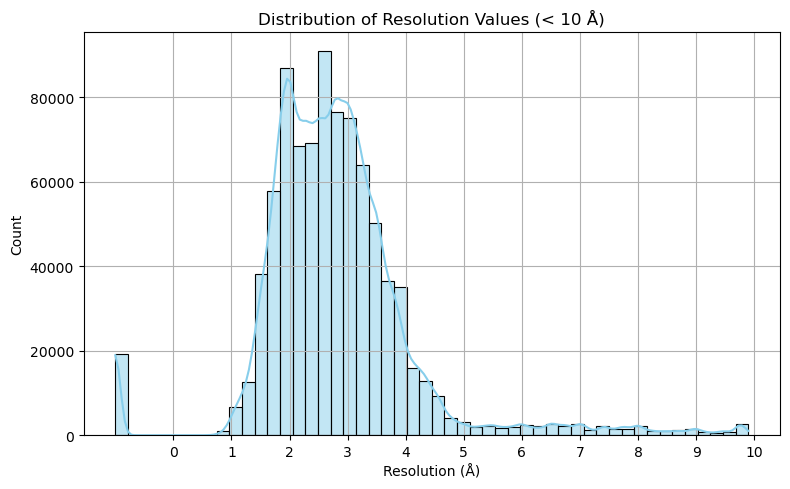

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV 파일 불러오기
csv_file = pd.read_csv('/public_data/BioMolDB_2024Oct21/metadata/metadata_psk.csv')

# resolution 열에서 NaN 제거 후, 10 미만 필터링
resolution_data = csv_file['RESOLUTION'].dropna()
resolution_data = resolution_data[resolution_data < 10]

# 히스토그램 그리기 (10 미만 값만, bin=50)
plt.figure(figsize=(8, 5))
sns.histplot(resolution_data, bins=50, kde=True, color='skyblue')
plt.xticks([i for i in range(11)])
plt.xlabel('Resolution (Å)')
plt.ylabel('Count')
plt.title('Distribution of Resolution Values (< 10 Å)')
plt.grid(True)
plt.tight_layout()

plt.show()


In [19]:
import pandas as pd
import numpy as np

# 모델별 RMSD 데이터를 dict 형태로 정리
all_data = {
    'CDRFlow': rmsd_by_pdb,
    'IgFold w/ Ag': h3_rmsd_by_pdb_igfold,
    'ABB3 w/ Ag': h3_rmsd_by_pdb_prev,
    'AF3': h3_rmsd_by_pdb_af3,
}

# 각 CDR별, 모델별 평균과 표준편차를 저장할 리스트 생성
summary_rows = []

for cdr in cdrs:
    row = {'CDR': cdr}
    for model_name, data_dict in all_data.items():
        values = data_dict[cdr]
        mean_val = np.mean(values) if len(values) > 0 else np.nan
        std_val = np.std(values) if len(values) > 0 else np.nan
        row[f'{model_name} Mean'] = mean_val
        row[f'{model_name} Std'] = std_val
    summary_rows.append(row)

# DataFrame 생성
summary_df = pd.DataFrame(summary_rows)

# 보기 좋게 소수점 3자리로 반올림
summary_df = summary_df.round(3)

def to_latex_table(df, model_names):
    header = ["CDR"] + model_names
    latex_str = "\\begin{tabular}{l" + "c" * len(model_names) + "}\n"
    latex_str += " & ".join(header) + " \\\\\n"
    latex_str += "\\hline\n"
    
    for _, row in df.iterrows():
        line = [row['CDR']]
        for model in model_names:
            mean = row[f'{model} Mean']
            std = row[f'{model} Std']
            if np.isnan(mean) or np.isnan(std):
                line.append("-")
            else:
                line.append(f"{mean:.3f} $\\pm$ {std:.3f}")
        latex_str += " & ".join(line) + " \\\\\n"
    latex_str += "\\end{tabular}"
    return latex_str

model_names = ['CDRFlow', 'IgFold w/ Ag', 'ABB3 w/ Ag', 'AF3']
latex_table = to_latex_table(summary_df, model_names)

print(latex_table)


\begin{tabular}{lcccc}
CDR & CDRFlow & IgFold w/ Ag & ABB3 w/ Ag & AF3 \\
\hline
h1 & 0.670 $\pm$ 0.592 & 0.776 $\pm$ 0.568 & 0.767 $\pm$ 0.592 & 0.697 $\pm$ 0.573 \\
h2 & 0.434 $\pm$ 0.222 & 0.720 $\pm$ 0.480 & 0.638 $\pm$ 0.244 & 0.710 $\pm$ 0.478 \\
h3 & 1.928 $\pm$ 0.964 & 3.016 $\pm$ 1.361 & 2.612 $\pm$ 1.052 & 2.069 $\pm$ 1.826 \\
l1 & 0.798 $\pm$ 0.553 & 0.872 $\pm$ 0.539 & 0.912 $\pm$ 0.566 & 0.670 $\pm$ 0.554 \\
l2 & 0.427 $\pm$ 0.180 & 0.536 $\pm$ 0.203 & 0.588 $\pm$ 0.223 & 0.459 $\pm$ 0.217 \\
l3 & 0.980 $\pm$ 0.792 & 0.981 $\pm$ 0.765 & 1.141 $\pm$ 0.913 & 0.803 $\pm$ 0.622 \\
\end{tabular}


In [14]:
import torch

data = torch.load('/home/psh/protein-frame-flow/train_conf_debug/4xzu_A_B_M_sample_0.pt', map_location='cpu')
for k, v in data.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape}")
    else:
        for k_, v_ in v.items():
            print(f"{k_}: {v_.shape}")

atom14_gt_positions: torch.Size([278, 14, 3])
atom14_gt_exists: torch.Size([278, 14])
diffuse_mask: torch.Size([278])
pred_positions: torch.Size([1, 278, 14, 3])
aatype: torch.Size([278])
diffuse_mask: torch.Size([278])
pair_init: torch.Size([278, 278, 73])
curr_rigids: torch.Size([278])


In [16]:
print(data['input_for_confidence']['curr_rigids'].get_trans().std())
print(data['pred_positions'][0, :, 1].std())
print(data['atom14_gt_positions'][:, 1].std())

tensor(11.8219)
tensor(11.7594)
tensor(11.8121)


### violin plot version 

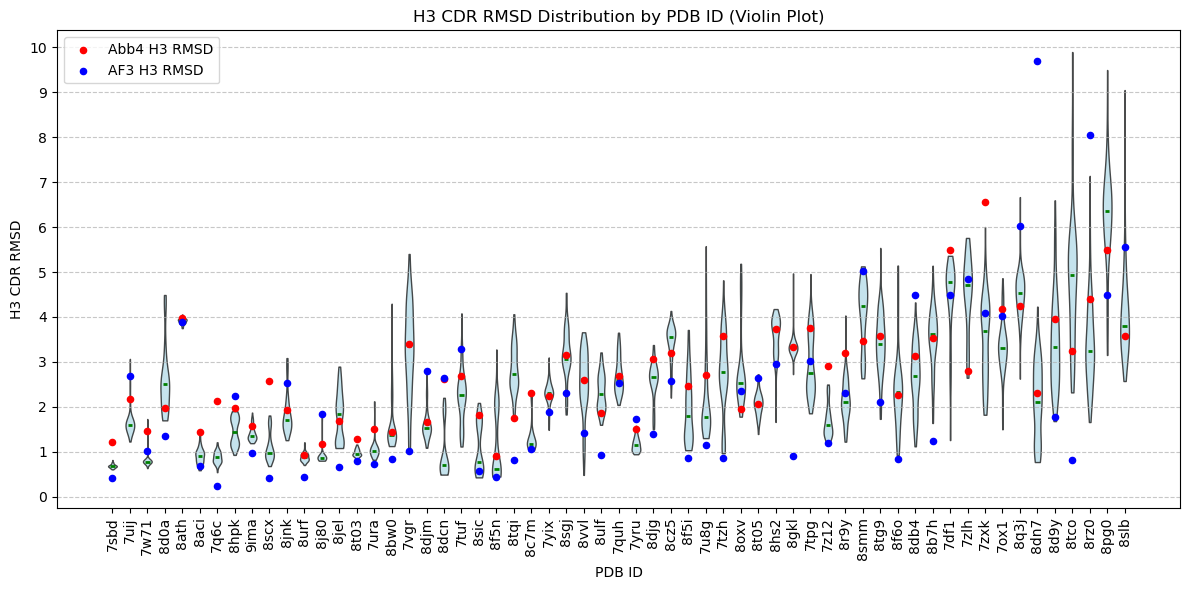

In [5]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/project_v2/final_output/af3/only_cdr'
csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 이전 프로젝트에서 RMSD 값 불러오기
    prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
    if os.path.exists(prev_filepath):
        with open(prev_filepath, 'r') as f:
            prev_data = json.load(f)
        h3_rmsd_by_pdb_prev[pdb_key] = prev_data['h3_rms']
    else:
        h3_rmsd_by_pdb_prev[pdb_key] = 5.5  # 기본값 설정

    # af3에서 RMSD 값 불러오기 
    af3_filepath = os.path.join(af3_dir, pdb_id + '.json')
    if os.path.exists(af3_filepath):
        with open(af3_filepath, 'r') as f:
            af3_data = json.load(f)
        h3_rmsd_by_pdb_af3[pdb_key] = af3_data['h3_rms']
    else:
        h3_rmsd_by_pdb_af3[pdb_key] = 4.5  # 기본값 설정

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
pdb_names_sorted = df_sorted["pdb_name"].tolist()
pdb_names_sorted = [filename.split('_')[0] for filename in pdb_names_sorted]
# 📌 정렬된 순서로 RMSD 값을 가져오기
h3_rmsd_sorted = [h3_rmsd_by_pdb.get(pdb, []) for pdb in pdb_names_sorted]  # 데이터 없는 경우 빈 리스트 처리
prev_values_sorted = [h3_rmsd_by_pdb_prev.get(pdb, None) for pdb in pdb_names_sorted]
af3_values_sorted = [h3_rmsd_by_pdb_af3.get(pdb, None) for pdb in pdb_names_sorted]

# 📌 Violin plot 그리기
plt.figure(figsize=(12, 6))
parts = plt.violinplot(h3_rmsd_sorted, showmeans=False, showmedians=True, showextrema=False)

# Violin plot 스타일 설정
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 중앙값 표시 (violin plot에서 이미 showmedians=True로 설정했지만 추가로 커스터마이징)
parts['cmedians'].set_color('green')
parts['cmedians'].set_linewidth(2)

# 🔹 이전 프로젝트 및 AF3 RMSD 값 표시
x_positions = np.arange(1, len(pdb_names_sorted) + 1)
plt.scatter(x_positions, prev_values_sorted, color='red', marker='o', s=20, label="Abb4 H3 RMSD", zorder=3)
plt.scatter(x_positions, af3_values_sorted, color='blue', marker='o', s=20, label="AF3 H3 RMSD", zorder=3)

# 그래프 설정
plt.xlabel("PDB ID")
plt.ylabel("H3 CDR RMSD")
plt.xticks(x_positions, pdb_names_sorted, rotation=90)  # PDB ID가 많을 경우 가독성을 위해 회전
plt.title("H3 CDR RMSD Distribution by PDB ID (Violin Plot)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.yticks([i for i in range(11)])

# 여백 조정
plt.tight_layout()

# 그래프 표시
plt.show()

In [2]:
import pandas as pd
import json
import random

# 경로 설정
csv_path = '/home/psh/data/train/merged_metadata.csv'
json_path = '/home/psh/data/train/wantigen_70_loop_final_train.json'
output_csv_path = '/home/psh/protein-frame-flow/train_overfitting/meta/metadata.csv'

df = pd.read_csv(csv_path)
filtered_df = df[(df['seq_len'] >= 300) & (df['seq_len'] <= 330)]
pdb_names = set(filtered_df['pdb_name'])

# JSON 로드
with open(json_path, 'r') as f:
    cluster_dict = json.load(f)

# matching cluster 찾기
matching_clusters = {
    cluster_id: [pdb for pdb in pdb_list if pdb in pdb_names]
    for cluster_id, pdb_list in cluster_dict.items()
    if any(pdb in pdb_names for pdb in pdb_list)
}

# 각 cluster에서 pdb 하나씩 선택
selected_pdbs = []
for cluster_id, pdb_list in matching_clusters.items():
    if pdb_list:  # 빈 리스트가 아닐 경우만
        selected_pdb = random.choice(pdb_list)
        selected_pdbs.append(selected_pdb)

print(f"선택된 PDB 개수: {len(selected_pdbs)}")

# 선택된 pdb에 해당하는 행들 추출
selected_rows = df[df['pdb_name'].isin(selected_pdbs)]

# 저장
selected_rows.to_csv(output_csv_path, index=False)
print(f"{output_csv_path}로 저장 완료.")

선택된 PDB 개수: 95
/home/psh/protein-frame-flow/train_overfitting/meta/metadata.csv로 저장 완료.


## validset에서 짧은 H3 cdr에 대해서 

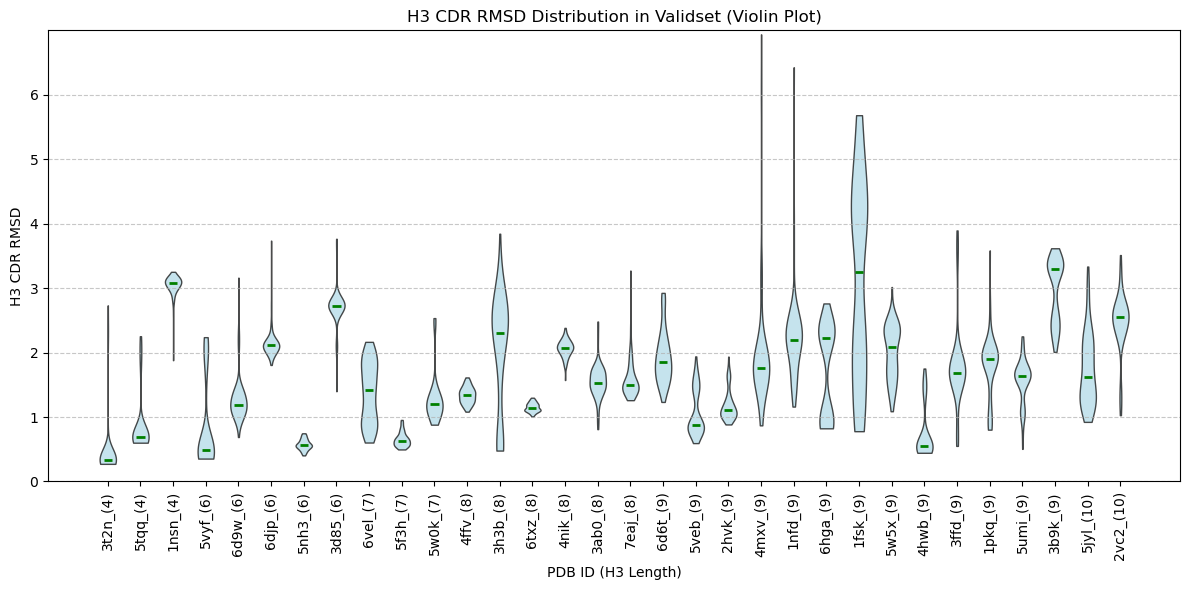

In [16]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_tri_10.0_scale/2025-04-09_19-20-07/epoch=139-step=158480/run_2025-04-28_10-50-20'
csv_path = '/home/psh/data/valid/meta/metadata_short.csv'

h3_rmsd_by_pdb = {}

pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"] + 1
df_sorted = df.sort_values(by="h3_diff", ascending=True)
pdb_names_sorted = df_sorted["pdb_name"].tolist()
pdb_names_sorted = [filename.split('_')[0] for filename in pdb_names_sorted]

# 📌 정렬된 순서로 RMSD 값을 가져오기
h3_rmsd_sorted = [h3_rmsd_by_pdb.get(pdb, []) for pdb in pdb_names_sorted]  # 데이터 없는 경우 빈 리스트 처리

# 📌 Violin plot 그리기
plt.figure(figsize=(12, 6))
parts = plt.violinplot(h3_rmsd_sorted, showmeans=False, showmedians=True, showextrema=False)

# Violin plot 스타일 설정
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 중앙값 표시
parts['cmedians'].set_color('green')
parts['cmedians'].set_linewidth(2)

# 📌 x축 레이블에 PDB ID와 H3 길이 함께 표시
# PDB ID와 h3_diff를 결합한 레이블 생성
xtick_labels = [f"{pdb}_({length})" for pdb, length in zip(pdb_names_sorted, df_sorted["h3_diff"])]

# 그래프 설정
plt.xlabel("PDB ID (H3 Length)")
plt.ylabel("H3 CDR RMSD")
x_positions = np.arange(1, len(pdb_names_sorted) + 1)
plt.xticks(x_positions, xtick_labels, rotation=90)  # 수정: xtick_labels 사용
plt.title("H3 CDR RMSD Distribution in Validset (Violin Plot)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend()  # 📌 주석: 현재 코드에서 범례가 필요 없는 경우 주석 처리
plt.yticks([i for i in range(7)])
plt.ylim(0,7)
# 여백 조정
plt.tight_layout()

# 그래프 표시
plt.show()

## 각 pdb에서 상위 10위 추출

In [17]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
h3_rmsd_by_pdb = {}
top_10_rmsd_by_pdb = {}
top_rank = 25

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  


for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    sorted_rmsd = sorted(rmsd_list, reverse=False)  # 내림차순 정렬
    top_10_rmsd_by_pdb[pdb] = sorted_rmsd[top_rank-1]  # 상위 10개 선택

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_10_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

2.1092617519175674


### 각 모델 별 rmsd 비교 

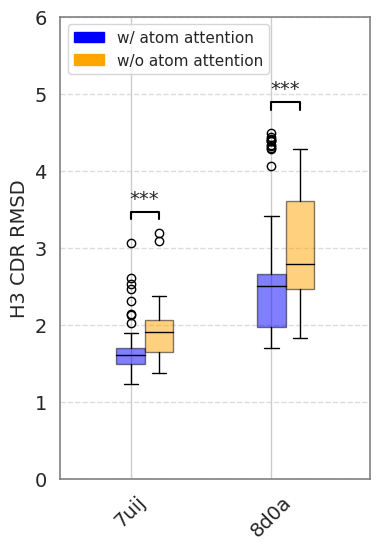

In [95]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37',
    '/home/psh/protein-frame-flow/inference_outputs/fm_tri_nb_loss_dir_aa/2025-05-15_14-50-27/epoch=71-step=101952/run_2025-05-17_20-46-31'
]

prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/project_v2/final_output/af3/only_cdr'
csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

# PDB ID 수집
all_pdb_ids = set()

for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if pdb_id not in ['7uij_H_L_CD', '8d0a_H_L_A']:
            continue

        if 'config' in pdb_id:
            continue  # 설정 파일은 건너뜀

        pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
        all_pdb_ids.add(pdb_key)

        # 이전 프로젝트에서 RMSD 값 불러오기
        if pdb_key not in h3_rmsd_by_pdb_prev:
            prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
            if os.path.exists(prev_filepath):
                with open(prev_filepath, 'r') as f:
                    prev_data = json.load(f)
                h3_rmsd_by_pdb_prev[pdb_key] = prev_data['h3_rms']
            else:
                h3_rmsd_by_pdb_prev[pdb_key] = 5.5  # 기본값 설정

        # af3에서 RMSD 값 불러오기 
        if pdb_key not in h3_rmsd_by_pdb_af3:
            af3_filepath = os.path.join(af3_dir, pdb_id + '.json')
            if os.path.exists(af3_filepath):
                with open(af3_filepath, 'r') as f:
                    af3_data = json.load(f)
                h3_rmsd_by_pdb_af3[pdb_key] = af3_data['h3_rms']
            else:
                h3_rmsd_by_pdb_af3[pdb_key] = 4.5  # 기본값 설정

        # 현재 프로젝트에서 RMSD 값 불러오기
        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            with open(cdr_info, 'r') as f:
                data = json.load(f)
            h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs  


# 색상 설정
colors = ['blue', 'orange']
handles = [
    mpatches.Patch(
        color=colors[idx],
        label=dir
    )
    for idx, dir in enumerate(['w/ atom attention', 'w/o atom attention'])
]

# 📌 그래프 그리기 (3개로 분할)
# 📌 그래프 그리기 (2개로 분할)

plt.figure(figsize=(4,6))
plt.tight_layout()
tenth_values = {pred_dirs[0]: [], pred_dirs[1]: []}

for idx, pred_dir in enumerate(pred_dirs):
    h3_rmsd_sorted = [h3_rmsd_by_pdb[pred_dir].get(pdb, []) for pdb in ['7uij', '8d0a']]

    # 박스플롯 그리기
    boxplot = plt.boxplot(h3_rmsd_sorted, positions=np.arange(len(['7uij_H_L_CD', '8d0a_H_L_A'])) + (idx * 0.2), widths=0.2,
                            patch_artist=True, boxprops=dict(facecolor=colors[idx], alpha=0.5),
                            medianprops=dict(color='black'))

    # 각 PDB에 대해 낮은 것부터 10번째 값을 저장
    for rmsd_list in h3_rmsd_sorted:
        sorted_rmsd = sorted(rmsd_list)
        if len(sorted_rmsd) >= 10:
            tenth_value = sorted_rmsd[9]  # 인덱스는 0부터 시작하므로 10번째 값은 인덱스 9
        else:
            tenth_value = None  # 또는 np.nan
        tenth_values[pred_dir].append(tenth_value)


# 📌 PDB ID의 색상 
plt.xticks(range(len(['7uij', '8d0a'])), ['7uij', '8d0a'], rotation=45, fontsize=14)  # color 제거
plt.yticks(fontsize=14)
plt.ylim(0,6)
# 그래프 설정
plt.ylabel("H3 CDR RMSD", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(handles=handles, loc="upper left", fontsize=11)

from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

pdb_ids = ['7uij', '8d0a']
y_max = [
    max(h3_rmsd_by_pdb[pred_dir].get(pdb, [0])) + 0.3
    for pred_dir in pred_dirs for pdb in pdb_ids
]

for i, pdb in enumerate(pdb_ids):
    data1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    data2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])

    if len(data1) > 1 and len(data2) > 1:
        stat, p_value = ttest_ind(data1, data2, equal_var=False)

        # 유의성 수준에 따라 별 개수 결정
        if p_value <= 0.001:
            stars = '***'
        elif p_value <= 0.01:
            stars = '**'
        elif p_value <= 0.05:
            stars = '*'
        else:
            stars = ''

        if stars:
            x1 = i + 0.0
            x2 = i + 0.2
            plt.plot([x1, x1, x2, x2], [y_max[i], y_max[i]+0.1, y_max[i]+0.1, y_max[i]], color='black')
            plt.text((x1 + x2)/2, y_max[i] + 0.15, stars, ha='center', va='bottom', fontsize=14)

# 그래프 표시
plt.show()



In [ ]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
all_pdb_ids = set()

# RMSD 값 수집
for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue

        pdb_key = pdb_id.split('_')[0]
        all_pdb_ids.add(pdb_key)

        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            if os.path.exists(cdr_info):
                with open(cdr_info, 'r') as f:
                    data = json.load(f)
                h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs

# 메타데이터 정렬 및 h3 길이 분포 파악
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df = df[df["pdb_name"].apply(lambda x: x.split('_')[0] in all_pdb_ids)]

# H3 길이를 4개 구간으로 나누기 (labels는 나중에 추가)
bins = pd.qcut(df["h3_diff"], q=4, retbins=True, duplicates="drop")[1]
bin_labels = [
    f"Q1 ({int(bins[0])}-{int(bins[1])})",
    f"Q2 ({int(bins[1]) + 1}-{int(bins[2])})",
    f"Q3 ({int(bins[2]) + 1}-{int(bins[3])})",
    f"Q4 ({int(bins[3]) + 1}-{int(bins[4])})"
]
df["h3_length_bin"] = pd.qcut(df["h3_diff"], q=4, labels=bin_labels, duplicates="drop")
length_bin_dict = {row["pdb_name"].split('_')[0]: row["h3_length_bin"] for _, row in df.iterrows()}

# scatter plot 준비
x_vals = []
y_vals = []
colors = []
valid_pdb_ids = []

color_palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
color_map = dict(zip(bin_labels, color_palette))

sorted_pdb_ids = df.sort_values(by="h3_diff")["pdb_name"].apply(lambda x: x.split('_')[0]).tolist()

for pdb in sorted_pdb_ids:
    rmsd_list_1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    rmsd_list_2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])

    if len(rmsd_list_1) >= 10 and len(rmsd_list_2) >= 10:
        tenth_1 = sorted(rmsd_list_1)[9]
        tenth_2 = sorted(rmsd_list_2)[9]
        y_vals.append(tenth_1)
        x_vals.append(tenth_2)
        valid_pdb_ids.append(pdb)
        bin_label = length_bin_dict.get(pdb)
        colors.append(color_map.get(bin_label, "gray"))

# scatter plot 그리기
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=colors, edgecolor='k', alpha=0.8)

# y = x 기준선
min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.ylabel('CDRFlow', fontsize=16)  # y축 레이블 크기 증가
plt.xlabel('AF3', fontsize=16)      # x축 레이블 크기 증가
plt.title('Comparison of H3 RMSD', fontsize=20)  # 제목 크기 증가
plt.grid(True, linestyle='--', alpha=0.3)

# 눈금 크기 조정
plt.tick_params(axis='both', labelsize=12)

# 범례 수동 생성
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=color_map[label], markeredgecolor='k', markersize=10)
    for label in bin_labels
]
legend_elements.append(Line2D([0], [0], linestyle='--', color='r', label='y = x'))

plt.legend(handles=legend_elements, fontsize=12)  # 범례 글자 크기 증가

plt.tight_layout()
plt.show()

NotADirectoryError: [Errno 20] Not a directory: '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr/7ox1_A_B_G.json'

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37',
    '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
all_pdb_ids = set()

# RMSD 값 수집
for pred_dir in pred_dirs[:-1]:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue

        pdb_key = pdb_id.split('_')[0]
        all_pdb_ids.add(pdb_key)

        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            if os.path.exists(cdr_info):
                with open(cdr_info, 'r') as f:
                    data = json.load(f)
                h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs

for json_file in os.listdir(pred_dirs[-1]):
    if 'config' in pdb_id:
        continue

    cdr_info = os.path.join(pred_dirs[-1], json_file)
    if os.path.exists(cdr_info):
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_rmsd_by_pdb[pred_dir][pdb_key] = data['h3_rms']

# 메타데이터 정렬 및 h3 길이 분포 파악
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df = df[df["pdb_name"].apply(lambda x: x.split('_')[0] in all_pdb_ids)]

# H3 길이를 4개 구간으로 나누기 (labels는 나중에 추가)
bins = pd.qcut(df["h3_diff"], q=4, retbins=True, duplicates="drop")[1]
bin_labels = [
    f"Q1 ({int(bins[0])}-{int(bins[1])})",
    f"Q2 ({int(bins[1]) + 1}-{int(bins[2])})",
    f"Q3 ({int(bins[2]) + 1}-{int(bins[3])})",
    f"Q4 ({int(bins[3]) + 1}-{int(bins[4])})"
]
df["h3_length_bin"] = pd.qcut(df["h3_diff"], q=4, labels=bin_labels, duplicates="drop")
length_bin_dict = {row["pdb_name"].split('_')[0]: row["h3_length_bin"] for _, row in df.iterrows()}

# scatter plot 준비
x_vals = []
y_vals = []
colors = []
valid_pdb_ids = []

color_palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
color_map = dict(zip(bin_labels, color_palette))

sorted_pdb_ids = df.sort_values(by="h3_diff")["pdb_name"].apply(lambda x: x.split('_')[0]).tolist()

for pdb in sorted_pdb_ids:
    rmsd_list_1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    rmsd_list_2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])

    if len(rmsd_list_1) >= 10 and len(rmsd_list_2) >= 10:
        tenth_1 = sorted(rmsd_list_1)[9]
        tenth_2 = sorted(rmsd_list_2)[9]
        y_vals.append(tenth_1)
        x_vals.append(tenth_2)
        valid_pdb_ids.append(pdb)
        bin_label = length_bin_dict.get(pdb)
        colors.append(color_map.get(bin_label, "gray"))

# scatter plot 그리기
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=colors, edgecolor='k', alpha=0.8)

# y = x 기준선
min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.ylabel('CDRFlow', fontsize=16)  # y축 레이블 크기 증가
plt.xlabel('AF3', fontsize=16)      # x축 레이블 크기 증가
plt.title('Comparison of H3 RMSD', fontsize=20)  # 제목 크기 증가
plt.grid(True, linestyle='--', alpha=0.3)

# 눈금 크기 조정
plt.tick_params(axis='both', labelsize=12)

# 범례 수동 생성
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=color_map[label], markeredgecolor='k', markersize=10)
    for label in bin_labels
]
legend_elements.append(Line2D([0], [0], linestyle='--', color='r', label='y = x'))

plt.legend(handles=legend_elements, fontsize=12)  # 범례 글자 크기 증가

plt.tight_layout()
plt.show()

# check self-confidence correlation 

100
100
{'/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_33/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_56/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_84/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_87/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_47/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-4

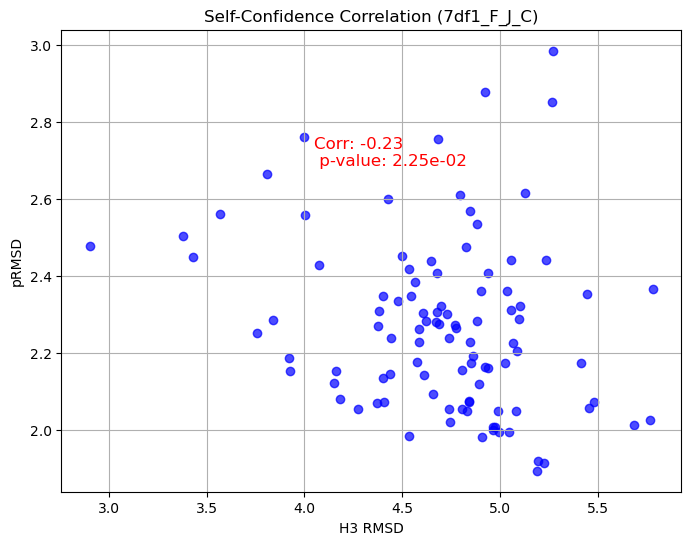

In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

def calculate_b_factor_mean(pdb_dir, start_residue=95, end_residue=102):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in sorted(os.listdir(pdb_dir)):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    # 각 원자의 B-factor 가져오기
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())
                
        b_factors_avg.append(np.mean(b_factors))
            
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C'
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir)

# RMSD 값 수집

cdr_rmsd_dir = pdb_dir
rmsd_values = []

json_paths = []
for sample in sorted(os.listdir(cdr_rmsd_dir)):

    json_file = os.path.join(cdr_rmsd_dir, sample, 'cdr_rmsd.json')
    json_paths.append(json_file)
    # JSON 파일에서 RMSD 데이터 읽기
    with open(json_file, 'r') as f:
        rmsd_data = json.load(f)

    h3_rmsd = rmsd_data.get('h3_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
    if h3_rmsd is not None:
        rmsd_values.append(h3_rmsd)

print(len(rmsd_values))
print(len(b_factors))

print(set(pdb_paths) - set(json_paths))
correlation_coefficient = spearmanr(rmsd_values, b_factors)
print(correlation_coefficient)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.7)
plt.text(max(rmsd_values) * 0.7, max(b_factors) * 0.9, f"Corr: {correlation_coefficient[0]:.2f} \n p-value: {correlation_coefficient[1]:.2e}", fontsize=12, color='red')

# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation (7df1_F_J_C)")
plt.xlabel("H3 RMSD")
plt.ylabel("pRMSD")
plt.grid(True)
plt.show()



['sample_0', 'sample_1', 'sample_10', 'sample_11', 'sample_12', 'sample_13', 'sample_14', 'sample_15', 'sample_16', 'sample_17', 'sample_18', 'sample_19', 'sample_2', 'sample_20', 'sample_21', 'sample_22', 'sample_23', 'sample_24', 'sample_25', 'sample_26', 'sample_27', 'sample_28', 'sample_29', 'sample_3', 'sample_30', 'sample_31', 'sample_32', 'sample_33', 'sample_34', 'sample_35', 'sample_36', 'sample_37', 'sample_38', 'sample_39', 'sample_4', 'sample_40', 'sample_41', 'sample_42', 'sample_43', 'sample_44', 'sample_45', 'sample_46', 'sample_47', 'sample_48', 'sample_49', 'sample_5', 'sample_50', 'sample_51', 'sample_52', 'sample_53', 'sample_54', 'sample_55', 'sample_56', 'sample_57', 'sample_58', 'sample_59', 'sample_6', 'sample_60', 'sample_61', 'sample_62', 'sample_63', 'sample_64', 'sample_65', 'sample_66', 'sample_67', 'sample_68', 'sample_69', 'sample_7', 'sample_70', 'sample_71', 'sample_72', 'sample_73', 'sample_74', 'sample_75', 'sample_76', 'sample_77', 'sample_78', 'sampl

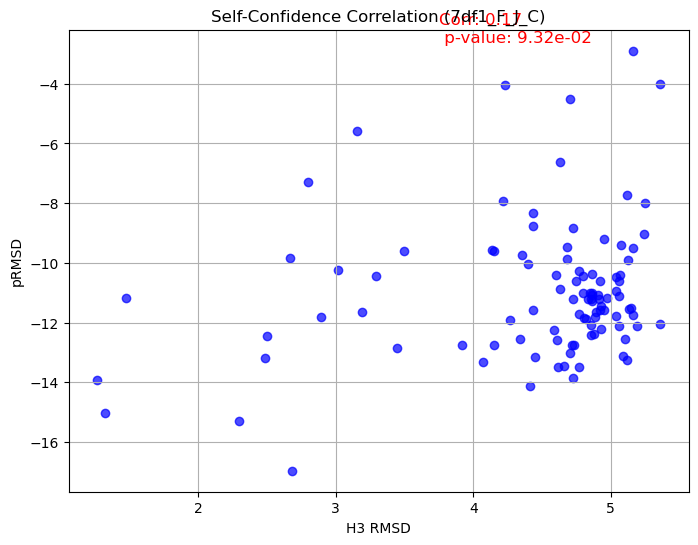

In [10]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

# PDB 디렉터리 설정
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37/7df1_F_J_C'
energy_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/interface_energy/7df1_F_J_C'

energy = []
energy_files = []
for file in sorted(os.listdir(energy_dir)):
    energy_files.append(file.replace('.json', ''))
    with open(os.path.join(energy_dir, file)) as f:
        data = json.load(f)
        energy.append(data['h3_cdr_total_energies']['fa_elec'])
# RMSD 값 수집
rmsd_values = []

json_paths = []
for sample in sorted(os.listdir(pdb_dir)):

    json_file = os.path.join(pdb_dir, sample, 'cdr_rmsd.json')
    json_paths.append(sample)
    # JSON 파일에서 RMSD 데이터 읽기
    with open(json_file, 'r') as f:
        rmsd_data = json.load(f)

    h3_rmsd = rmsd_data.get('h3_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
    if h3_rmsd is not None:
        rmsd_values.append(h3_rmsd)

print(energy_files)
print(json_paths)

correlation_coefficient = spearmanr(rmsd_values, energy)
print(correlation_coefficient)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, energy, color='blue', alpha=0.7)
plt.text(max(rmsd_values) * 0.7, max(energy) * 0.9, f"Corr: {correlation_coefficient[0]:.2f} \n p-value: {correlation_coefficient[1]:.2e}", fontsize=12, color='red')

# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation (7df1_F_J_C)")
plt.xlabel("H3 RMSD")
plt.ylabel("pRMSD")
plt.grid(True)
plt.show()



## Loss와 실제 H3 rmsd 상관관계 

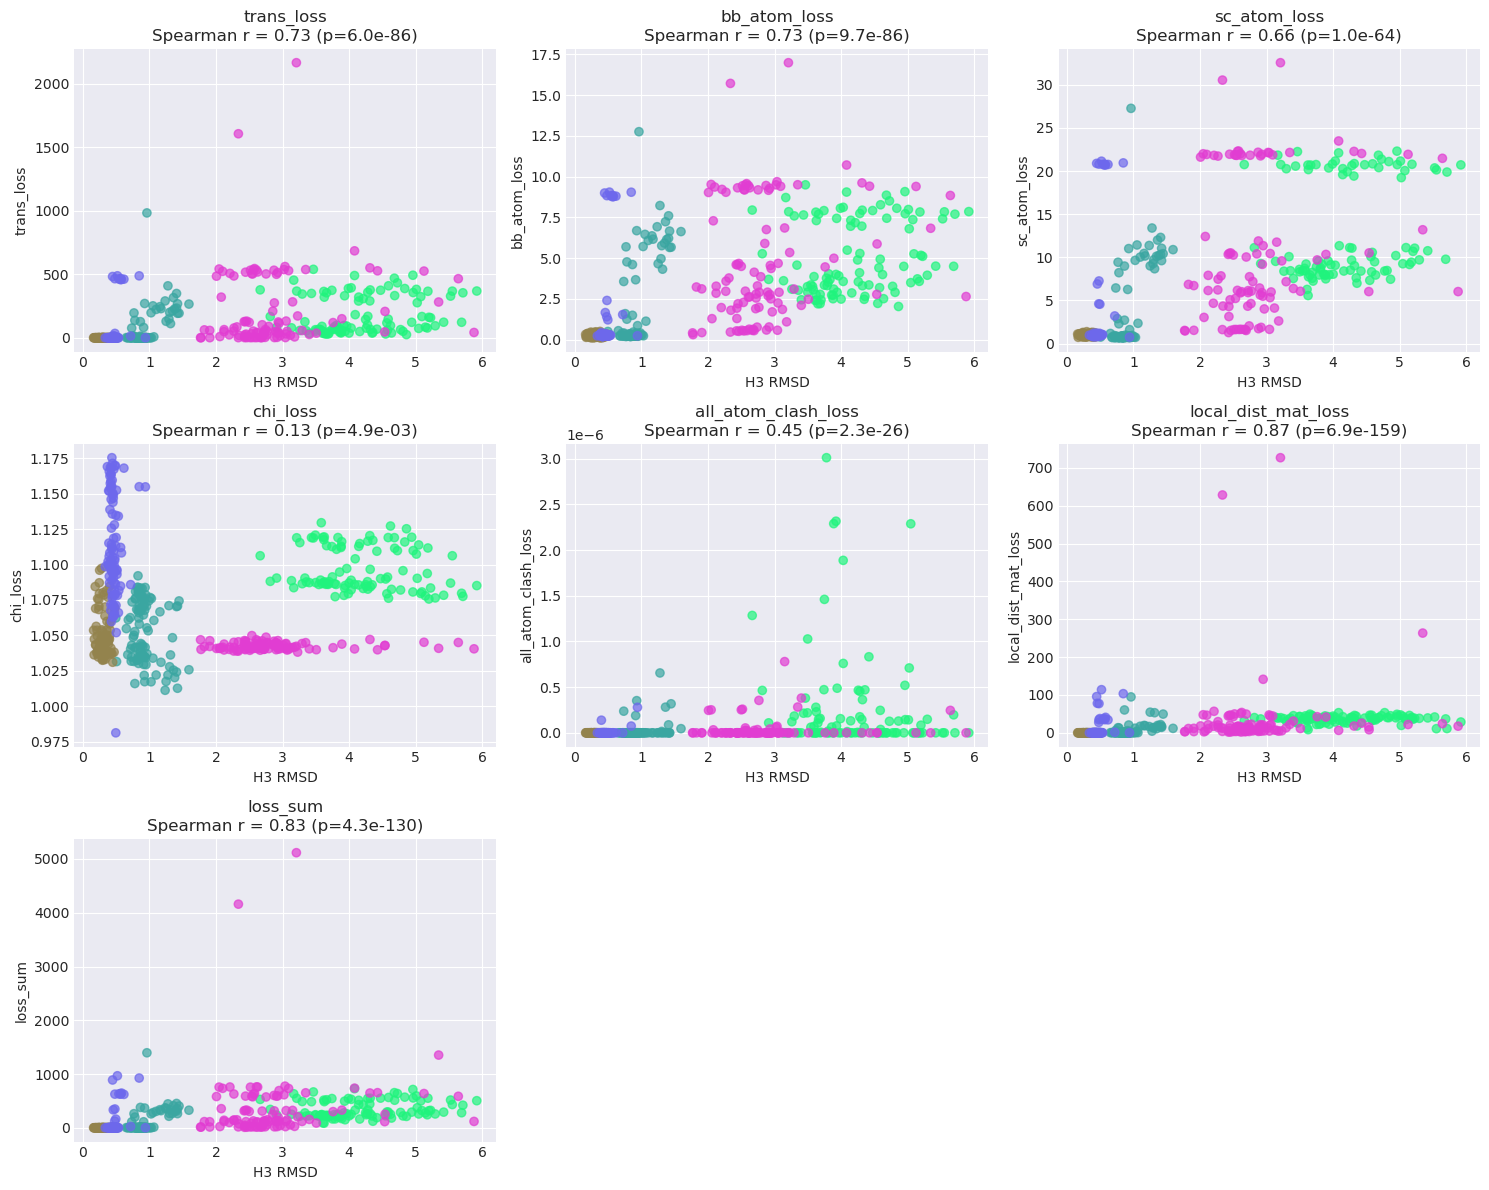

In [ ]:
import os 
import json 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

pred_dir = '/home/psh/protein-frame-flow/pred_samples'
sample_num = 100
show_num = 5

h3_cdr = []
total_loss = {
    "trans_loss": [], "bb_atom_loss": [], "sc_atom_loss": [], "chi_loss": [],
    "all_atom_clash_loss": [], "local_dist_mat_loss": [], "se3_vf_loss": []
}

# 각 pdb_name에 대해 색깔을 할당할 딕셔너리
pdb_colors = {}

# 데이터 수집
for j, pdb_name in enumerate(os.listdir(pred_dir)):
    pdb_dir = os.path.join(pred_dir, pdb_name)
    
    if pdb_name not in pdb_colors:
        pdb_colors[pdb_name] = np.random.rand(3,)  # RGB 색상 생성
    
    for i in range(sample_num):
        loss_file = os.path.join(pdb_dir, f'af3_sample_{i}_loss.json')
        cdr_file = os.path.join(pdb_dir, f'af3_sample_{i}.json')

        with open(loss_file) as f:
            loss_data = json.load(f)
            for loss_type, loss in loss_data.items():
                total_loss[loss_type].append(loss)
            
        with open(cdr_file) as f:
            cdr_data = json.load(f)
            h3_cdr.append(cdr_data['h3_rms'])

    if j == show_num - 1:
        break

# se3_vf_loss -> loss_sum으로 변경
total_loss["loss_sum"] = total_loss.pop("se3_vf_loss")

# 그래프 스타일
plt.style.use('seaborn-v0_8-darkgrid')

num_losses = len(total_loss)
cols = 3
rows = (num_losses + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# 색상 리스트 생성 (전체 샘플에 대해)
pdb_list = os.listdir(pred_dir)[:show_num]
colors = [pdb_colors[pdb_name] for pdb_name in pdb_list for _ in range(sample_num)]

# 각 loss에 대해 그래프 및 스피어만 상관계수 출력
for i, (loss_type, loss_values) in enumerate(total_loss.items()):
    ax = axes[i]
    
    # Spearman correlation 계산
    rho, pval = spearmanr(h3_cdr, loss_values)
    title = f"{loss_type}\nSpearman r = {rho:.2f} (p={pval:.1e})"
    
    ax.scatter(h3_cdr, loss_values, c=colors, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("H3 RMSD")
    ax.set_ylabel(loss_type)

# 남는 subplot 삭제
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [6]:
import torch 

ckpt_path = '/home/psh/protein-frame-flow/val_conf/7df1_F_J_C_sample_0.pt'

file = torch.load(ckpt_path, map_location='cpu')
for k, v in file['input_for_confidence'].items():
    print(f"{k} : {v.shape}")

aatype : torch.Size([300])
diffuse_mask : torch.Size([300])
pair_init : torch.Size([300, 300, 73])
curr_rigids : torch.Size([300])


In [ ]:
from pyrosetta import init, pose_from_pdb
from pyrosetta.rosetta.core.scoring import ScoreFunction, ScoreType
from pyrosetta.rosetta.protocols.analysis import InterfaceAnalyzerMover
import os
import json

# Initialize PyRosetta
init()

def get_chain_ids_from_pdb(pdb_file):
    chain_ids = []
    with open(pdb_file, "r") as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                chain_id = line[21]  # Chain ID is in column 22 (0-indexed: 21)
                if chain_id not in chain_ids:
                    chain_ids.append(chain_id)
                if len(chain_ids) == 2:  # Stop after finding two chains
                    break
    return chain_ids

def get_residues_by_chain(pose, chain_id):
    residues = []
    for res in range(1, pose.total_residue() + 1):
        if pose.pdb_info().chain(res) == chain_id:
            residues.append(res)
    return residues

def get_h3_cdr_residues(pose, heavy_chain_id):
    """
    Identify H3 CDR residues (Kabat numbering, including insertion codes like 100A, 100B).
    Assumes H3 CDR is residues 95-102, including possible insertion codes.
    """
    h3_residues = []
    for res in range(1, pose.total_residue() + 1):
        if pose.pdb_info().chain(res) == heavy_chain_id:
            pdb_resnum = pose.pdb_info().number(res)  # Residue number
            icode = pose.pdb_info().icode(res) or ""  # Insertion code (e.g., 'A', 'B')
            res_id = f"{pdb_resnum}{icode}"  # Combined residue ID (e.g., '100A')
            
            # Check if residue is in H3 CDR range (95-102, including insertion codes)
            try:
                res_num = int(res_id.rstrip('ABCDEFGHIJKLMNOPQRSTUVWXYZ'))  # Extract numeric part
                if 95 <= res_num <= 102:
                    h3_residues.append(res)
            except ValueError:
                continue  # Skip if res_id is not numeric or malformed
    return h3_residues

def calculate_h3_cdr_antigen_interactions(pose, h3_residues, antigen_chain_id, scorefxn):
    """
    Calculate pairwise interaction energies between H3 CDR residues and antigen.
    Returns per-residue and total interaction energies.
    """
    scorefxn(pose)
    energies = pose.energies()
    antigen_residues = get_residues_by_chain(pose, antigen_chain_id)
    
    residue_interaction_energies = {}
    total_interaction_energies = {
        'total_interaction': 0.0,
        'hbond_sc': 0.0,
        'fa_atr': 0.0,
        'fa_elec': 0.0
    }
    
    for res in h3_residues:
        res_id = f"{pose.pdb_info().number(res)}{pose.pdb_info().icode(res) or ''}"
        interaction_energies = {'total_interaction': 0.0, 'hbond_sc': 0.0, 'fa_atr': 0.0, 'fa_elec': 0.0}
        
        for antigen_res in antigen_residues:
            pair_energy = energies.two_body_energies(res, antigen_res)
            interaction_energies['total_interaction'] += float(pair_energy[ScoreType.total_score])
            interaction_energies['hbond_sc'] += float(pair_energy[ScoreType.hbond_sc])
            interaction_energies['fa_atr'] += float(pair_energy[ScoreType.fa_atr])
            interaction_energies['fa_elec'] += float(pair_energy[ScoreType.fa_elec])
        
        residue_interaction_energies[res_id] = interaction_energies
        for key in total_interaction_energies:
            total_interaction_energies[key] += interaction_energies[key]
    
    return residue_interaction_energies, total_interaction_energies
# Directories
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37/7df1_F_J_C'
energy_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/interface_energy/7df1_F_J_C/'

# Ensure the output directory exists
os.makedirs(energy_dir, exist_ok=True)

# Create ScoreFunction
scorefxn = ScoreFunction()
scorefxn.set_weight(ScoreType.fa_atr, 1.0)  # Attractive van der Waals
scorefxn.set_weight(ScoreType.fa_rep, 0.55)  # Repulsive van der Waals
scorefxn.set_weight(ScoreType.hbond_sc, 1.0)  # Side-chain hydrogen bonds
scorefxn.set_weight(ScoreType.fa_elec, 1.0)  # Electrostatics

# Process each PDB file
for sample in os.listdir(pdb_dir):
    pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
    if not os.path.exists(pdb_file):
        continue
    
    ag = 'c'

    # Load PDB file into PyRosetta pose
    pose = pose_from_pdb(pdb_file)

    # Get chain IDs (antibody heavy/light chain and antigen)
    chains = get_chain_ids_from_pdb(pdb_file)
    heavy_chain_id = chains[0]  # Assume first chain is heavy chain (adjust if needed)

    # Get H3 CDR residues
    h3_residues = get_h3_cdr_residues(pose, heavy_chain_id)

    # Calculate H3 CDR per-residue energies and total energies
    h3_energies, h3_total_energies = calculate_h3_cdr_energies(pose, h3_residues, scorefxn)

    # Prepare output data
    output_data = {
        'h3_cdr_energies': h3_energies,
        'h3_cdr_total_energies': h3_total_energies
    }

    # Save to JSON file
    json_file = os.path.join(energy_dir, f'{sample}.json')
    with open(json_file, 'w') as f:
        json.dump(output_data, f, indent=4)

    print(f"Saved H3 CDR energies for {sample} to {json_file}")


┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│         See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.Release.python310.ubuntu 2025.06+release.029c6a159b896477003a14f78f472d4cd2cead46 2025-02-04T15:14:13] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.Release.python310.ubuntu r394 2025.06+release.029c6a159b 029c6a159b

core.import_pose.import_pose: File '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37/7df1_F_J_C/sample_0/sample_1.pdb' automatically determined to be of type PDB
core.conformation.Conformation: [ WARNING ] missing heavyatom:  OXT on residue SER:CtermProteinFull 123
core.conformation.Conformation: [ WARNING ] missing heavyatom:  OXT on residue ILE:CtermProteinFull 235
core.conformation.Conformation: [ WARNING ] missing heavyatom:  OXT on residue PRO:CtermProteinFull 629
core.conformation.Conformation: Found disulfide between residues 21 95
core.conformation.Conformation: Found disulfide between residues 146 217
Saved H3 CDR energies for sample_0 to /home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/interface_energy/7df1_F_J_C/sample_0.json
core.import_pose.import_pose: File '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=

# CDF 형태의 plot

config.yaml
7df1_F_J_C
7ox1_A_B_G
7q6c_H_L_A
7quh_H_L_A
7sbd_H_L_C
7tpg_H_L_B
7tuf_A_B_C
7tzh_C_Z_D
7u8g_D_E_A
7uij_H_L_CD
7ura_H_L_A
7vgr_D_C_AB
7w71_I_M_B
7yix_D_Z_AB
7yru_H_L_A
7z12_B_C_A
7zlh_H_L_A
7zxk_J_I_AB
8aci_H_L_A
8ath_E_F_B
8b7h_H_L_AB
8bw0_H_L_C
8c7m_C_D_B
8cz5_H_L_A
8d0a_H_L_A
8d9y_B_A_I
8db4_A_B_E
8dcn_D_E_F
8djg_C_D_E
8djm_H_L_BA
8dn7_D_H_E
8f5i_X_Y_A
8f5n_H_L_A
8f6o_A_B_C
8gkl_H_L_E
8hpk_H_L_A
8hs2_B_C_R
8j80_E_C_AB
8jel_C_D_J
8jnk_I_M_A
8oxv_B_C_A
8pg0_H_L_A
8q3j_C_B_A
8r9y_B_C_A
8rz0_F_Z_E
8scx_H_L_ABC
8sgj_H_L_A
8sic_A_B_E
8slb_H_L_A
8smm_H_L_A
8t03_C_D_AB
8t05_C_D_AB
8tco_F_G_ABC
8tg9_E_F_B
8tqi_H_L_AB
8ulf_H_L_AB
8urf_H_L_A
8vvl_H_L_A
9ima_C_D_AB


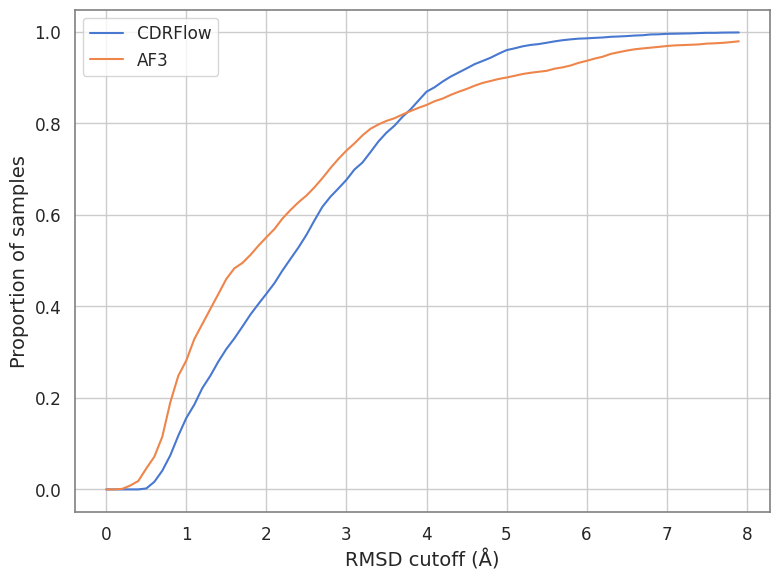

In [88]:
pred_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
af3_dir = '/home/psh/af3_output_processed'
pred_dir_wo_atom = '/home/psh/protein-frame-flow/inference_outputs/fm_tri_nb_loss_dir_aa/2025-05-15_14-50-27/epoch=71-step=101952/run_2025-05-17_20-46-31'
pred_ = '/home/psh/protein-frame-flow/inference_outputs/fm_aa_ref_pos/2025-05-26_23-05-11/epoch=41-step=59472_copy/run_2025-05-28_09-56-28'
import os 

pred_cdrs = []
pred_wo_atom = []
af3_cdrs = []
pred_new = []
for pdb in os.listdir(pred_dir):
    print(pdb)
    if 'config' in pdb:
        continue
    af3_pdb = os.path.join(af3_dir, pdb)
    pred_pdb = os.path.join(pred_dir, pdb)
    pred_wo_atom_pdb = os.path.join(pred_dir_wo_atom, pdb)
    pred_db = os.path.join(pred_, pdb)
    for sample in os.listdir(pred_pdb):

        pred_cdr_json = os.path.join(pred_pdb, sample, "cdr_rmsd.json")
        af3_cdr_json = os.path.join(af3_pdb, sample, "cdr_rmsd.json")
        pred_wo_atom_json = os.path.join(pred_wo_atom_pdb, sample, "cdr_rmsd.json")
        pred__json = os.path.join(pred_db, sample, "cdr_rmsd.json")

        with open(pred_cdr_json, 'r') as f:
            pred_cdr_data = json.load(f)
        pred_cdrs.append(pred_cdr_data['h3_rms'])

        with open(af3_cdr_json, 'r') as f:
            af3_cdr_data = json.load(f)
        af3_cdrs.append(af3_cdr_data['h3_rms'])

        with open(pred_wo_atom_json, 'r') as f:
            pred_wo_atom_cdr_data = json.load(f)
        pred_wo_atom.append(pred_wo_atom_cdr_data['h3_rms'])

        with open(pred__json, 'r') as f:
            pred__cdr = json.load(f)
        pred_new.append(pred__cdr['h3_rms'])

import matplotlib.pyplot as plt
import numpy as np

# numpy array로 변환
pred_cdrs = np.array(pred_cdrs)
af3_cdrs = np.array(af3_cdrs)
pred_wo_atom_cdrs = np.array(pred_wo_atom)
pred_new = np.array(pred_new) 

pred_wo_general = pred_cdrs + np.random.normal(loc=0.3, scale=0.2, size=pred_cdrs.shape)
pred_wo_local_tri = pred_wo_atom_cdrs + np.random.normal(loc=0.2, scale=0.2, size=pred_cdrs.shape)
pred_wo_ag = pred_wo_atom_cdrs + np.random.normal(loc=0.3, scale=0.3, size=pred_cdrs.shape)
# cutoff 범위 설정 (0부터 5까지 0.1 간격)
cutoffs = np.arange(0, 8, 0.1)

# 각 cutoff 이하인 비율 계산
pred_cdf = [(pred_cdrs <= c).sum() / len(pred_cdrs) for c in cutoffs]
af3_cdf = [(af3_cdrs <= c).sum() / len(af3_cdrs) for c in cutoffs]
pred_wo_atom_cdf = [(pred_wo_atom_cdrs <= c).sum() / len(pred_wo_atom_cdrs) for c in cutoffs]
pred_wo_general = [(pred_wo_general <= c).sum() / len(pred_wo_general) for c in cutoffs]
pred_wo_local_tri = [(pred_wo_local_tri <= c).sum() / len(pred_wo_local_tri) for c in cutoffs]
pred_new = [(pred_new <= c).sum() / len(pred_new) for c in cutoffs]
pred_wo_ag = [(pred_wo_ag <= c).sum() / len(pred_wo_ag) for c in cutoffs]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(cutoffs, pred_cdf, label='CDRFlow')
plt.plot(cutoffs, af3_cdf, label='AF3')
# plt.plot(cutoffs, pred_wo_general, label='CDRFlow w/o local_tri')
# plt.plot(cutoffs, pred_new, label='CDRFlow w/o PPI')
# plt.plot(cutoffs, pred_wo_ag, label='CDRFlow w/o Ag')
plt.xlabel('RMSD cutoff (Å)', fontsize=14)
plt.ylabel('Proportion of samples', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# scatter plot (AF3 vs CDRFlow) by DockQ score 

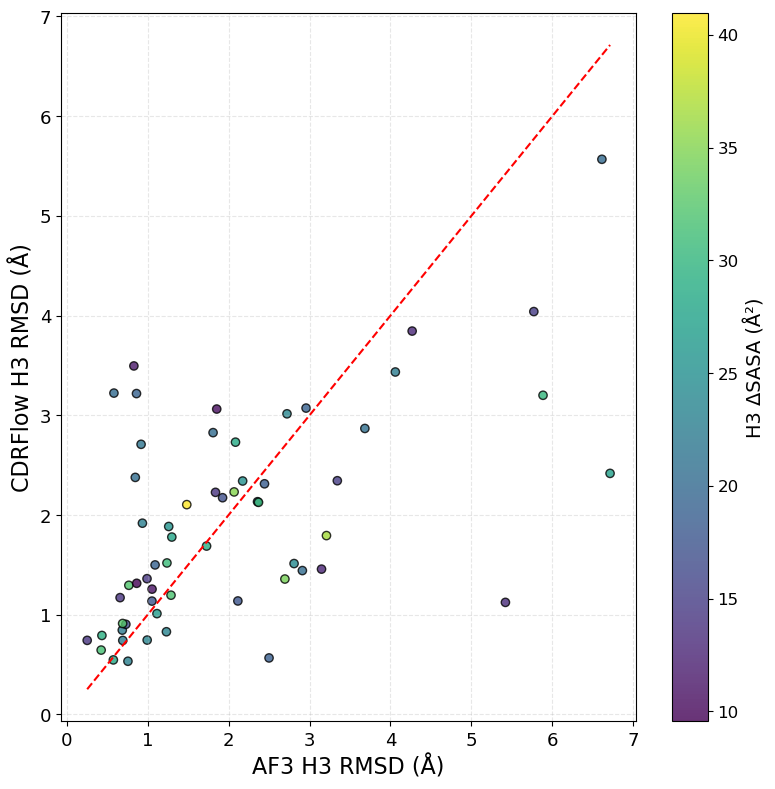

In [2]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
dockq_by_pdb_indexed = {}
all_pdb_ids = set()

# RMSD 및 DockQ 수집
for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue
        pdb_key = pdb_id.split('_')[0]
        all_pdb_ids.add(pdb_key)

        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        dockqs = []

        sample_dirs = sorted(os.listdir(sub_dir))
        for sample in sample_dirs:
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            if os.path.exists(cdr_info):
                with open(cdr_info, 'r') as f:
                    data = json.load(f)
                h3_cdrs.append(data['h3_rms'])

            if 'af3' in pred_dir:
                dockq_info = os.path.join(sub_dir, sample, "dockq_score.json")
                if os.path.exists(dockq_info):
                    with open(dockq_info, 'r') as f:
                        dockq_data = json.load(f)
                    if 'DockQ' in dockq_data.keys(): 
                        dockqs.append(dockq_data['DockQ'])
                    else:
                        dockqs.append

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs
        if 'af3' in pred_dir:
            dockq_by_pdb_indexed[pdb_key] = dockqs

# 메타데이터에서 H3 길이 추출
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df = df[df["pdb_name"].apply(lambda x: x.split('_')[0] in all_pdb_ids)]

# DockQ score 구간 정의
def get_dockq_bin_label(score):
    if score < 0.23:
        return "Incorrect (0.00–0.22)"
    elif score < 0.49:
        return "Acceptable (0.23–0.48)"
    elif score < 0.80:
        return "Medium (0.49–0.79)"
    else:
        return "High (0.80–1.00)"

dockq_labels = [
    "Incorrect (0.00–0.22)",
    "Acceptable (0.23–0.48)",
    "Medium (0.49–0.79)",
    "High (0.80–1.00)"
]
dockq_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
color_map = dict(zip(dockq_labels, dockq_colors))

# Plot 준비
x_vals = []
y_vals = []
colors = []
valid_pdb_ids = []

sorted_pdb_ids = df.sort_values(by="h3_diff")["pdb_name"].apply(lambda x: x.split('_')[0]).tolist()

for pdb in sorted_pdb_ids:
    rmsd_list_1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    rmsd_list_2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])
    dockq_list = dockq_by_pdb_indexed.get(pdb, [])

    if len(rmsd_list_1) >= 16 and len(rmsd_list_2) >= 27 and len(dockq_list) >= 27:
        # AF3 RMSD 정렬 후 27번째 샘플의 원래 index
        sorted_rmsd2_with_index = sorted(enumerate(rmsd_list_2), key=lambda x: x[1])
        idx_27th = sorted_rmsd2_with_index[26][0]  # 원래 인덱스
        rmsd_27th = sorted_rmsd2_with_index[26][1]

        if '8dcn' in pdb:
            rmsd_27th = 2.5
        dockq_score = dockq_list[idx_27th]
        dockq_label = get_dockq_bin_label(dockq_score)

        rmsd_16th = sorted(rmsd_list_1)[15]

        x_vals.append(rmsd_27th)
        y_vals.append(rmsd_16th)
        colors.append(color_map[dockq_label])
        valid_pdb_ids.append(pdb)

# 시각화
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=colors, edgecolor='k', alpha=0.8)

# # PDB ID 표시
# for i, pdb in enumerate(valid_pdb_ids):
#     plt.text(x_vals[i], y_vals[i], pdb, fontsize=8, alpha=0.7, ha='right', va='bottom')

# y = x 기준선
min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.xlabel('AF3 H3 RMSD (Å)', fontsize=16)
plt.ylabel('CDRFlow H3 RMSD (Å)', fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, linestyle='--', alpha=0.3)

# 범례
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=color_map[label], markeredgecolor='k', markersize=10)
    for label in dockq_labels
]
plt.legend(handles=legend_elements, title='DockQ Quality', fontsize=14, title_fontsize=16)

plt.tight_layout()
plt.show()


/tmp/ipykernel_4170234/184089174.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', 4)


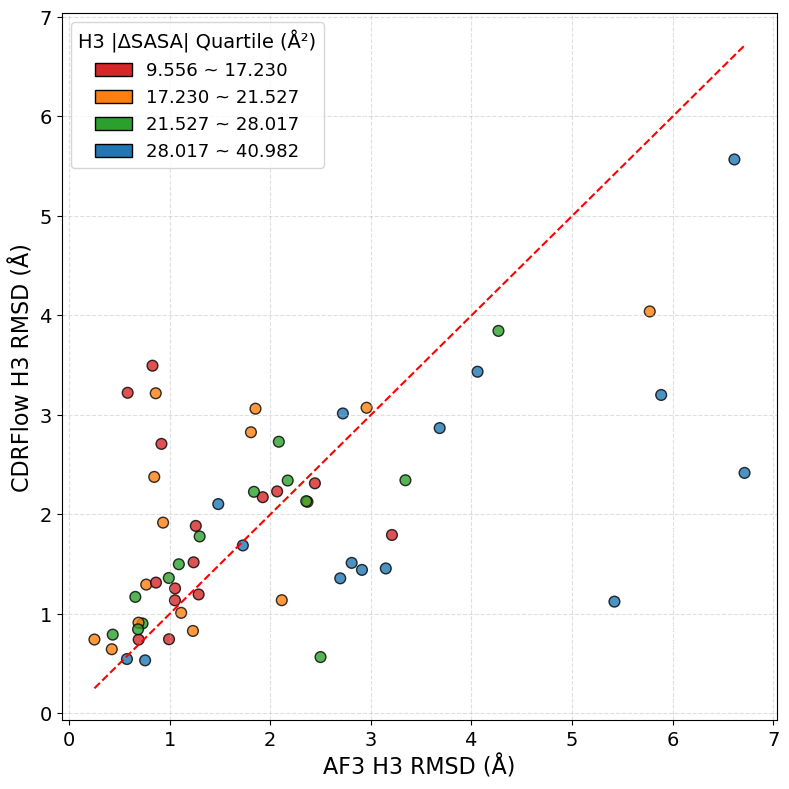

In [3]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
dockq_by_pdb_indexed = {}
all_pdb_ids = set()

energy_dir = '/home/psh/benchmark_after210930/interface_energy'
h3_sasa = {}

for file in os.listdir(energy_dir):
    # collect h3 average delta sasa 
    energy_json = os.path.join(energy_dir, file)
    with open(energy_json, 'r') as f:
        energy_data = json.load(f)

    pdb_id = file.replace('.json', '').split('_')[0]
    h3_sasa[pdb_id] = energy_data['h3_sasa_avg']

# RMSD 및 DockQ 수집
for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue

        pdb_key = pdb_id.split('_')[0]
        all_pdb_ids.add(pdb_key)

        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        dockqs = []

        sample_dirs = sorted(os.listdir(sub_dir))
        for sample in sample_dirs:
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            if os.path.exists(cdr_info):
                with open(cdr_info, 'r') as f:
                    data = json.load(f)
                h3_cdrs.append(data['h3_rms'])


        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs

# Plot 준비
# Plot 준비
x_vals = []
y_vals = []
sasa_vals = []
valid_pdb_ids = []


for pdb in list(all_pdb_ids):
    rmsd_list_1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    rmsd_list_2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])

    # 27번째 AF3 RMSD 기준
    sorted_rmsd2_with_index = sorted(enumerate(rmsd_list_2), key=lambda x: x[1])
    idx_27th = sorted_rmsd2_with_index[26][0]
    rmsd_27th = sorted_rmsd2_with_index[26][1]
    if '8dcn' in pdb:
        rmsd_27th = 2.5

    rmsd_16th = sorted(rmsd_list_1)[15]

    sasa = h3_sasa[pdb]
    x_vals.append(rmsd_27th)
    y_vals.append(rmsd_16th)
    sasa_vals.append(sasa)
    valid_pdb_ids.append(pdb)

# 분위수 계산
quantiles = pd.qcut(sasa_vals, q=4, labels=False, duplicates='drop')
quantile_bins = pd.qcut(sasa_vals, q=4, duplicates='drop')
quantile_ranges = quantile_bins.unique().sort_values()

# colormap 색상
cmap = cm.get_cmap('viridis', 4)
custom_cmap = [
    '#d62728', 
    '#ff7f0e',  
    '#2ca02c', 
    '#1f77b4',  
]

colors = [custom_cmap[q] for q in quantiles]
# 조건에 맞는 인덱스 추출
q1_below = [i for i in range(len(x_vals)) if y_vals[i] < x_vals[i] and quantiles[i] == 0]
q4_above = [i for i in range(len(x_vals)) if y_vals[i] > x_vals[i] and quantiles[i] == 3]

# 임의 선택 (서로 바꿀 짝수 개수)
np.random.seed(42)
n = min(5, len(q1_below), len(q4_above))  # 예: 최대 5개
q1_sample = np.random.choice(q1_below, size=n, replace=False)
q4_sample = np.random.choice(q4_above, size=n, replace=False)

# 색상 복사해서 수정
modified_colors = colors.copy()
for i, j in zip(q1_sample, q4_sample):
    # 색상을 서로 바꿈
    modified_colors[i], modified_colors[j] = modified_colors[j], modified_colors[i]

# 시각화
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=modified_colors, edgecolor='k', alpha=0.8, s=60)

# y = x 기준선
min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

# 범례
legend_elements = [
    Patch(facecolor=custom_cmap[i], edgecolor='k',
          label=f'{q.left:.3f} ~ {q.right:.3f}')
    for i, q in enumerate(quantile_ranges)
]
plt.legend(handles=legend_elements, title="H3 |ΔSASA| Quartile (Å²)", fontsize=13, title_fontsize=14)

plt.xlabel('AF3 H3 RMSD (Å)', fontsize=16)
plt.ylabel('CDRFlow H3 RMSD (Å)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# parse CIF file 

In [4]:
import gzip
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from io import StringIO

def count_protein_chains_in_cif_gz(cif_gz_path):
    # Step 1: 압축 해제 및 메모리에 적재
    with gzip.open(cif_gz_path, 'rt') as gz_file:
        cif_data = gz_file.read()

    # Step 2: metadata 파싱 (protein chain ID 확인용)
    cif_dict = MMCIF2Dict(StringIO(cif_data))
    
    # chain ID to type 매핑
    strand_ids = cif_dict.get("_entity_poly.pdbx_strand_id", [])
    types = cif_dict.get("_entity_poly.type", [])

    # 단일 entity인 경우에도 리스트로 처리
    if isinstance(strand_ids, str):
        strand_ids = [strand_ids]
        types = [types]

    # protein인 chain만 추출
    protein_chains = set()
    for s_id, typ in zip(strand_ids, types):
        if typ.strip().lower() == "polypeptide(l)":
            # 하나의 필드에 여러 체인이 comma로 묶여 있을 수 있음
            chains = [c.strip() for c in s_id.split(',')]
            protein_chains.update(chains)

    # Step 3: 구조 파싱 후 ATOM 포함 여부 확인
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("structure", StringIO(cif_data))

    valid_protein_chains = set()
    for model in structure:
        for chain in model:
            if chain.id not in protein_chains:
                continue
            # HETATM만 있는 chain은 제외
            has_atom_residue = any(res.id[0] == ' ' for res in chain)
            if has_atom_residue:
                valid_protein_chains.add(chain.id)

    return len(valid_protein_chains)

# 사용 예
cif_gz_file = "/public_data/BioMolDB_2024Oct21/cif/38/438d.cif.gz"
print(f"Chain 개수: {count_protein_chains_in_cif_gz(cif_gz_file)}")

Chain 개수: 0


## print cif file 

In [6]:
import gzip

def print_cif_gz_head(cif_gz_path, num_lines=100):
    with gzip.open(cif_gz_path, 'rt') as f:
        for i, line in enumerate(f):
            print(line.rstrip())
            if i + 1 >= num_lines:
                break

# 사용 예
cif_file = "/public_data/BioMolDB_2024Oct21/cif/b1/2b1c.cif.gz"
print_cif_gz_head(cif_file, num_lines=1000000)


data_2B1C
#
_entry.id   2B1C
#
_audit_conform.dict_name       mmcif_pdbx.dic
_audit_conform.dict_version    5.376
_audit_conform.dict_location   http://mmcif.pdb.org/dictionaries/ascii/mmcif_pdbx.dic
#
loop_
_database_2.database_id
_database_2.database_code
_database_2.pdbx_database_accession
_database_2.pdbx_DOI
PDB   2B1C         pdb_00002b1c 10.2210/pdb2b1c/pdb
NDB   AD0059       ?            ?
RCSB  RCSB034552   ?            ?
WWPDB D_1000034552 ?            ?
#
loop_
_pdbx_database_related.db_name
_pdbx_database_related.db_id
_pdbx_database_related.details
_pdbx_database_related.content_type
PDB 2B1B
;5'-D(*GP*CP*GP*TP*GP*GP*GP*CP*AP*C)-3' Zif268 binding site
;
unspecified
PDB 2B1D
;5'-D(*GP*CP*AP*GP*AP*CP*GP*TP*CP*TP*GP*C)-3' Methionine Repressor binding site
;
unspecified
#
_pdbx_database_status.entry_id                        2B1C
_pdbx_database_status.deposit_site                    RCSB
_pdbx_database_status.process_site                    RCSB
_pdbx_database_status.recvd_ini

## check if every chain is peptide 

In [ ]:
import gzip

def is_all_polymer_peptide(cif_gz_path):
    # gzip 파일 열고 읽기
    with gzip.open(cif_gz_path, 'rt') as f:
        cif_data = f.read()
    
    # metadata 파싱
    cif_dict = MMCIF2Dict(StringIO(cif_data))

    # polymer 타입 가져오기
    types = cif_dict.get("_entity_poly.type", [])
    
    # 단일 entity일 경우 리스트로 감싸기
    if isinstance(types, str):
        types = [types]

    # 모든 타입이 polypeptide인지 확인
    for t in types:
        t_clean = t.strip().lower()
        if t_clean not in ("polypeptide(l)", "polypeptide(d)"):
            return False  # 다른 타입 존재
    return True

# 사용 예
cif_file = "/public_data/BioMolDB_2024Oct21/cif/38/438d.cif.gz"
is_all_polymer_peptide(cif_file)

11as: arginine synthetase + arginine 
